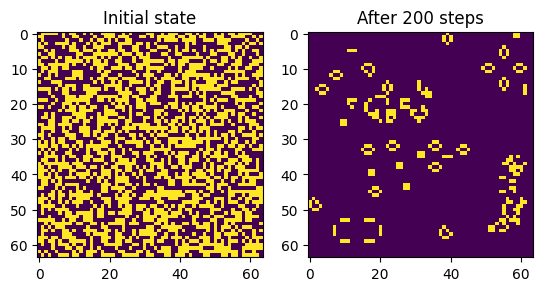

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

import hashlib

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class GameOfLife:

    def __init__(
        self, 
        board_size=(64, 64),
        device=torch.device('cuda'), 
        dtype=torch.float16,
        init_density=0.15
        ):

        self.board_size = board_size
        self.device = device
        self.dtype = dtype
        self.init_density = init_density
        
        self.kernel = torch.tensor( # 1x1x3x3 game of life kernel
            [[[[1, 1, 1], 
               [1, 0, 1], 
               [1, 1, 1]]]], dtype=self.dtype, device=self.device)

    def init_state(self, batch_size=1, init_density=None):

        if init_density is None:
            init_density = self.init_density
        shape = (batch_size, 1, self.board_size[0], self.board_size[1])
        state = torch.bernoulli(
            torch.full(shape, init_density, dtype=self.dtype, device=self.device)
        )
        return state

    def step(self, state):

        with torch.no_grad():
            # apply a convolution with zero padding
            state_padded = F.pad(state, (1, 1, 1, 1), mode='constant', value=0)
            neighborhood_sum = F.conv2d(state_padded, self.kernel)
            new_state = torch.zeros_like(state, dtype=self.dtype, device=self.device)
            new_state = torch.where(neighborhood_sum == 3, 1, new_state)
            new_state = torch.where(neighborhood_sum == 2, state, new_state)
            return new_state

    def draw(self, state, return_first=True):
        """
        Draws the state as an RGB image.
        If return_first is True, returns the first element of the batch.
        If return_first is False, returns the entire batch as a numpy array.    
        """
        if state.shape[0] > 1 and return_first:
            return state[0].cpu().numpy().transpose(1, 2, 0)
        elif state.shape[0] > 1 and not return_first:
            return state.cpu().numpy().transpose(1, 2, 0)
        else:
            return state.squeeze(0).cpu().numpy().transpose(1, 2, 0)

#--------------------------------------------------------------------------------------------------------------
# Example usage

game = GameOfLife()
init_state = game.init_state(
    batch_size=1,
    init_density=0.5
)

num_frames = 200
frames = [game.draw(init_state)]

# Accumulate all frames
current_state = init_state.clone()
for i in range(num_frames):
    next_state = game.step(current_state)
    frames.append(game.draw(next_state))
    current_state = next_state

# Draw initial and final state side by side
fig, axs = plt.subplots(1, 2)
axs[0].imshow(frames[0])
axs[0].set_title("Initial state")
axs[1].imshow(frames[-1])
axs[1].set_title(f"After {num_frames} steps")
plt.show()

# Now, create the animation
fig_anim, ax_anim = plt.subplots()
im = ax_anim.imshow(frames[0])
ax_anim.axis('off')

def animate(i):
    im.set_data(frames[i])
    return [im]

ani = animation.FuncAnimation(
    fig_anim, animate, frames=len(frames), interval=200, blit=True)

plt.close(fig_anim)  # Prevents duplicate static plot

# Display the animation in the notebook
display(HTML(ani.to_jshtml()))




In [ ]:
def compute_state_hash(state):
    """
    Computes a hash of the tensor, used for cycle detection
    """
    state_bytes = state.cpu().numpy().tobytes()
    return hashlib.md5(state_bytes).digest()


def evolve_until_cycle(game_of_life, initial_state, verbose=True, plot_interval=1000):
    """
    Evolve the cellular automaton until a cycle is detected.
    
    Args:
        game_of_life: GameOfLife instance
        initial_state: Initial state tensor
        verbose: Whether to print progress
        plot_interval: How often to plot (if verbose=True)
    
    Returns:
        steps_to_cycle: Number of steps until cycle was detected
        total_cell_changes: Total number of cell state changes across all steps
        cycle_period: Length of the detected cycle
        final_state: The final state when cycle was detected
    """
    state = initial_state.clone()  # Don't modify the input
    state_history = {}  # Maps state hash to step number
    total_cell_changes = 0
    
    # Store initial state
    state_hash = compute_state_hash(state)
    state_history[state_hash] = 0
    
    i = 0
    while True:
        prev_state = state
        state = game_of_life.step(state)
        i += 1
        
        # Count cell changes (cells that flipped)
        cell_changes = torch.sum(torch.abs(state - prev_state)).item()
        total_cell_changes += cell_changes
        
        # Check for cycle
        state_hash = compute_state_hash(state)
        if state_hash in state_history:
            cycle_period = i - state_history[state_hash]
            
            if verbose:
                print(f"\n✓ Cycle detected at step {i}!")
                print(f"  Previous occurrence at step {state_history[state_hash]}")
                print(f"  Cycle period: {cycle_period}")
                print(f"  Total cell changes: {total_cell_changes:,}")
                print(f"  Avg changes per step: {total_cell_changes / i:.2f}")
                print(f"  Memory used: ~{len(state_history) * 24 / 1024:.2f} KB for {len(state_history)} unique states")
            
            return i, total_cell_changes, cycle_period, state
        
        state_history[state_hash] = i
        
        if verbose and i % plot_interval == 0:
            print(f"Step {i:,}, unique states: {len(state_history)}, "
                  f"cell changes so far: {total_cell_changes:,}, "
                  f"memory: ~{len(state_history) * 24 / 1024:.2f} KB")
            plt.figure(figsize=(8, 8))
            plt.imshow(game_of_life.draw(state))
            plt.title(f"Step {i}")
            plt.axis('off')
            plt.show()


In [ ]:


def perturb_single_cell(state):
    """
    Add one living cell to the grid by selecting a *dead* cell within the 2-cell
    neighborhood (5x5 grid) of any living cell. This avoids perturbing irrelevant regions.
    
    Args:
        state: Current state tensor [batch, channels, height, width]
    
    Returns:
        perturbed_state: State with one dead cell turned alive
        (row, col): Coordinates of the perturbed cell
    """
    state_perturbed = state.clone()
    dtype = state.dtype
    living_mask = (state[0, 0] > 0)  # shape [H, W], bool
    living = living_mask.to(dtype).unsqueeze(0).unsqueeze(0)  # shape [1, 1, H, W]

    # Use max pooling to get the 2-cell (5x5) neighborhood (dilated neighborhood)
    neighborhood = torch.nn.functional.max_pool2d(
        living, kernel_size=5, stride=1, padding=2
    )[0,0]  # shape [H, W]

    neighborhood_mask = (neighborhood > 0)  # bool, [H, W]
    candidate_mask = neighborhood_mask & (~living_mask)  # only dead cells near living ones

    # Find all coordinates within the candidate mask
    coords = torch.nonzero(candidate_mask, as_tuple=False)

    if coords.size(0) == 0:
        raise ValueError(
            "No eligible dead cells found within the 5x5 neighborhood of living cells "
            "(either there are no living cells, or the neighborhood is fully occupied)."
        )

    # Randomly pick a coordinate from the valid ones
    idx = torch.randint(0, coords.size(0), (1,)).item()
    row, col = coords[idx].tolist()

    # Make the dead cell alive
    state_perturbed[0, 0, row, col] = state_perturbed.new_tensor(1.0)

    return state_perturbed, (row, col)


def run_perturbation_experiment(
    game_of_life, 
    initial_state, 
    num_warmup_perturbations=10000,
    num_perturbations=10000, 
    verbose=True):
    
    # Step 1: Run initial state until convergence
    if verbose:
        print("Step 1: Running initial state until convergence...")
    
    steps_initial, changes_initial, period_initial, stable_state = evolve_until_cycle(
        game_of_life, 
        initial_state, 
        verbose=False
    )
    
    if verbose:
        print(f"  Initial convergence: {steps_initial} steps, period {period_initial}")
        print(f"  Starting perturbation experiment...\n")
    
    # Step 2: Perturb and measure convergence repeatedly
    results = []
    
    if verbose:
        print(f"Step 2: Running {num_warmup_perturbations} warmup perturbations...")

    for i in range(num_warmup_perturbations):
        if verbose and i % (num_warmup_perturbations // 10) == 0:
            print(f"  Perturbation {i+1}/{num_warmup_perturbations}")
        perturbed_state, (row, col) = perturb_single_cell(stable_state)
        _, _, _, new_stable = evolve_until_cycle(
            game_of_life,
            perturbed_state,
            verbose=False
        )
        stable_state = new_stable
        
    if verbose:
        print(f"Step 3: Running {num_perturbations} perturbations...")
        
    for i in range(num_perturbations):
        if verbose and i % (num_perturbations // 10) == 0:
            print(f"  Perturbation {i+1}/{num_perturbations}")
        
        # Perturb one cell
        perturbed_state, (row, col) = perturb_single_cell(stable_state)
        
        # Run until convergence
        steps, changes, period, new_stable = evolve_until_cycle(
            game_of_life,
            perturbed_state,
            verbose=False
        )
        
        results.append({
            'steps': steps,
            'changes': changes,
            'period': period,
            'perturbation_coord': (row, col)
        })
        
        stable_state = new_stable
        
        if verbose and (i + 1) % 10000 == 0:
            print(f"  Perturbation {i+1}/{num_perturbations}")
    
    return results, stable_state

In [27]:
board_size = 100
init_density = 0.5

num_warmup_perturbations = 0
num_perturbations = 10000

game_of_life = GameOfLife(
    board_size=(board_size, board_size),
    device=device,
    init_density=init_density,
)
# Initialize
state = game_of_life.init_state()

# Run experiment
results, final_stable = run_perturbation_experiment(
    game_of_life,
    state,
    num_warmup_perturbations=num_warmup_perturbations,
    num_perturbations=num_perturbations,
    verbose=True
)

Step 1: Running initial state until convergence...
  Initial convergence: 1099 steps, period 2
  Starting perturbation experiment...

Step 2: Running 0 warmup perturbations...
Step 3: Running 10000 perturbations...
  Perturbation 1/10000
  Perturbation 1001/10000
  Perturbation 2001/10000
  Perturbation 3001/10000
  Perturbation 4001/10000
  Perturbation 5001/10000
  Perturbation 6001/10000
  Perturbation 7001/10000
  Perturbation 8001/10000
  Perturbation 9001/10000
  Perturbation 10000/10000

✓ Experiment complete!


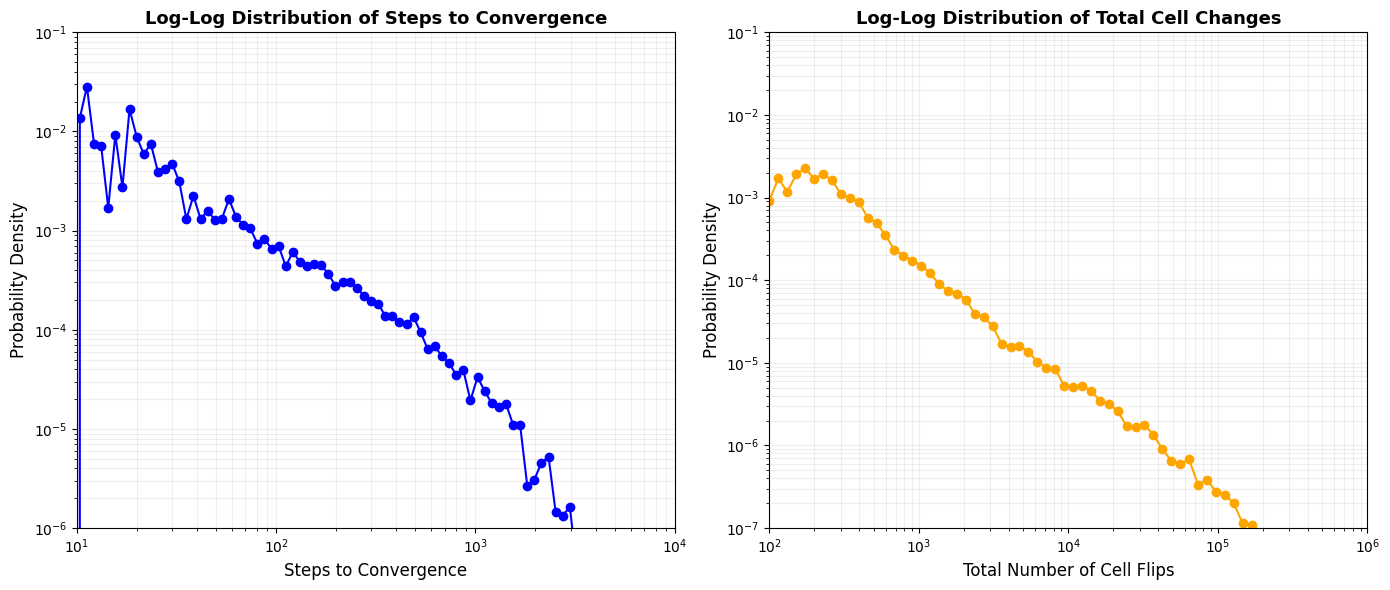

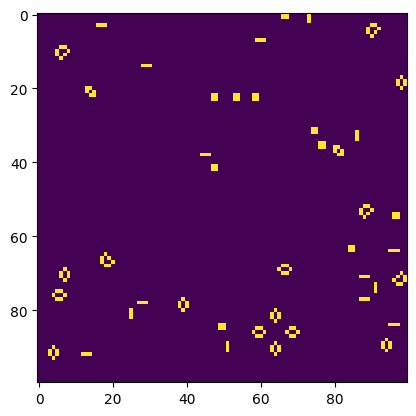

In [69]:
# Prepare data for log-log plots
steps_list = [r['steps'] for r in results]
changes_list = [r['changes'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Log-log plot for steps to convergence (normalized to probability distribution)
counts_steps, bins_steps = np.histogram(
    steps_list, bins=np.logspace(np.log10(1), np.log10(max(steps_list)+1), 100), density=True
)
centers_steps = np.sqrt(bins_steps[:-1] * bins_steps[1:])  # bin geometric mean for log-log
axes[0].plot(centers_steps, counts_steps, marker='o', linestyle='-', color='blue')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Steps to Convergence', fontsize=12)
axes[0].set_ylabel('Probability Density', fontsize=12)
axes[0].set_title('Log-Log Distribution of Steps to Convergence', fontsize=13, fontweight='bold')
axes[0].grid(True, which="both", alpha=0.2)
axes[0].set_ylim(1e-6, 1e-1)  # Set y-axis between 10^-10 and 10^
axes[0].set_xlim(1e1, 1e4)  # Set y-axis between 10^-10 and 10^-1 (log-scale)

# Log-log plot for number of cell changes (normalized to probability distribution)
counts_changes, bins_changes = np.histogram(
    changes_list, bins=np.logspace(np.log10(1), np.log10(max(changes_list)+1), 100), density=True
)
centers_changes = np.sqrt(bins_changes[:-1] * bins_changes[1:])
axes[1].plot(centers_changes, counts_changes, marker='o', linestyle='-', color='orange')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Total Number of Cell Flips', fontsize=12)
axes[1].set_ylabel('Probability Density', fontsize=12)
axes[1].set_title('Log-Log Distribution of Total Cell Changes', fontsize=13, fontweight='bold')
axes[1].grid(True, which="both", alpha=0.2)
axes[1].set_ylim(1e-7, 1e-1)  # Set y-axis between 10^-10 and 10^-1 (log-scale)
axes[1].set_xlim(1e2, 1e6)  # Set y-axis between 10^-10 and 10^

plt.tight_layout()
plt.show()

#plot final state
plt.imshow(game_of_life.draw(final_stable))
plt.show()

The code below runs the same experiment multiple times, then plots then plots the distributions both separate and merged.

In [56]:
board_size = 100
init_density = 0.5

num_warmup_perturbations = 10000
num_perturbations = 10000

results_list = []
final_states_list = []

num_experiments = 10

for i in range(num_experiments):
    print(f"Experiment {i+1}/{num_experiments}")
    game_of_life = GameOfLife(
        board_size=(board_size, board_size),
        device=device,
        init_density=init_density,
    )
    state = game_of_life.init_state()
    results, final_stable = run_perturbation_experiment(
        game_of_life,
        state,
        num_warmup_perturbations=num_warmup_perturbations,
        num_perturbations=num_perturbations,
        verbose=False
    )
    results_list.append(results)
    final_states_list.append(final_stable.detach().cpu())


Experiment 1/10
Experiment 2/10
Experiment 3/10
Experiment 4/10
Experiment 5/10
Experiment 6/10
Experiment 7/10
Experiment 8/10
Experiment 9/10
Experiment 10/10


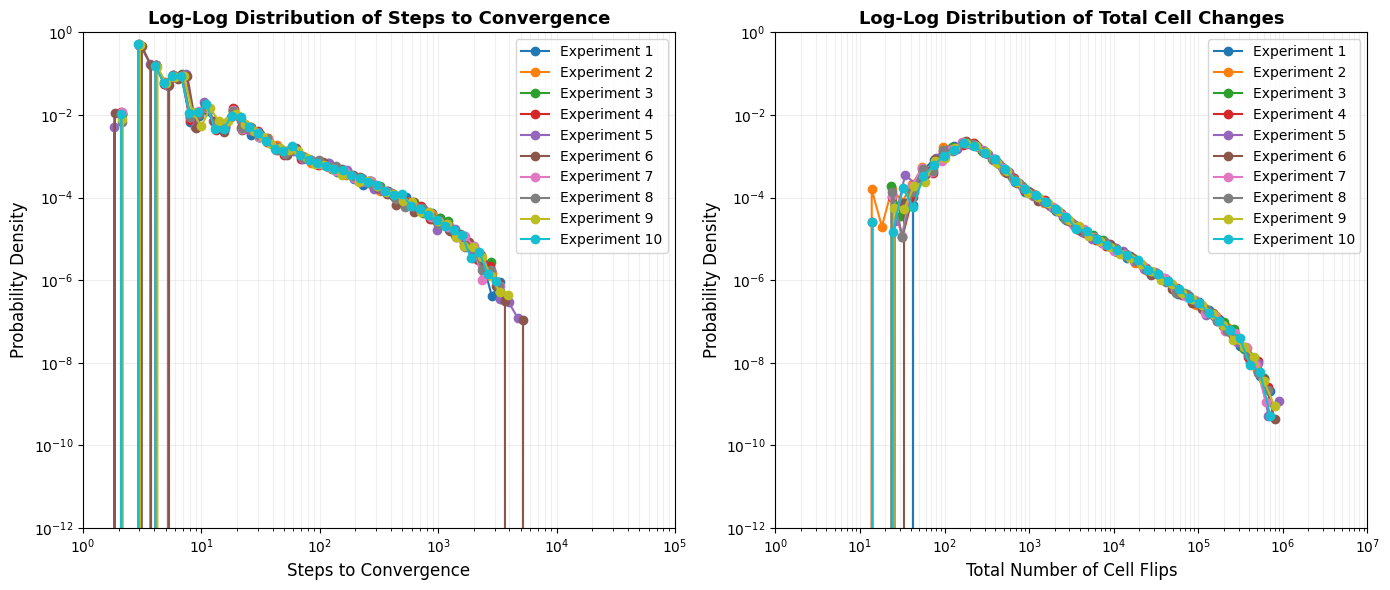

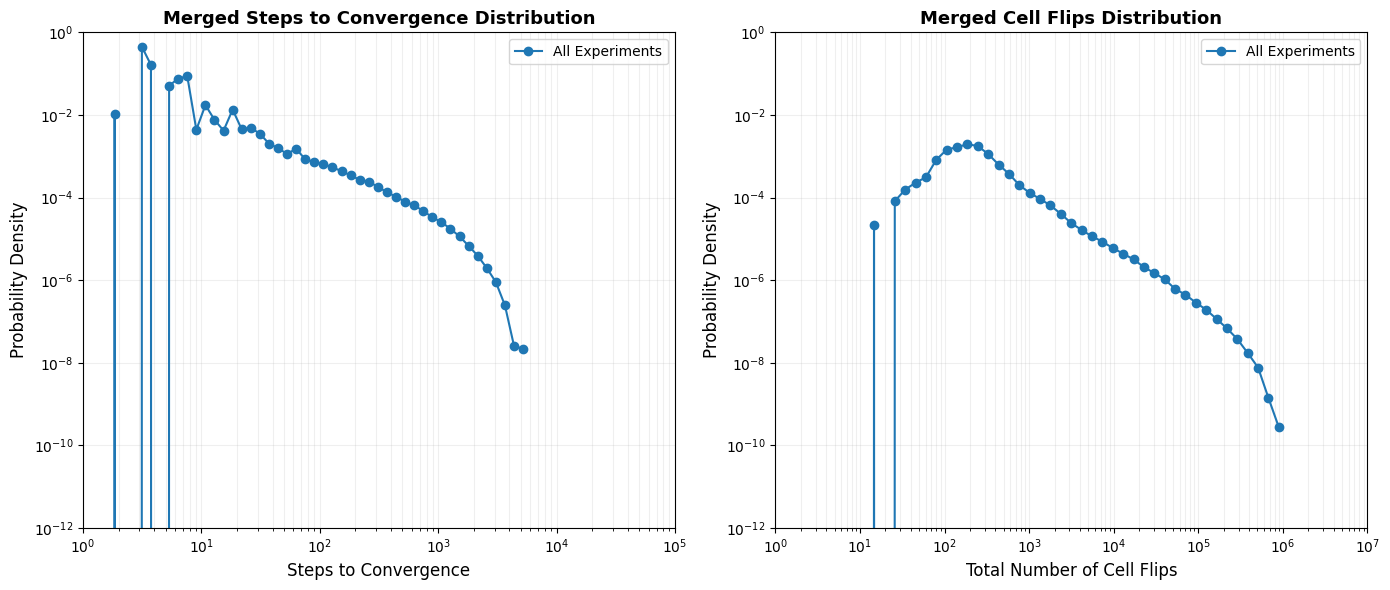

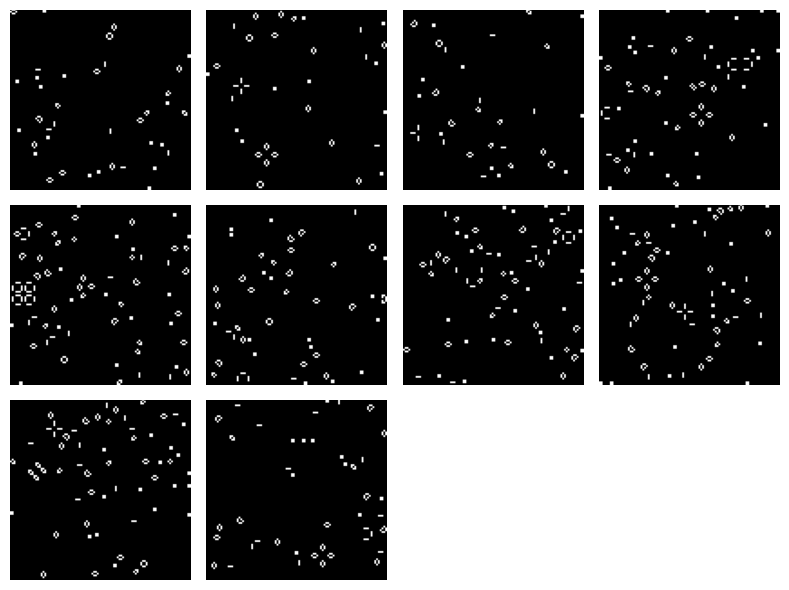

In [68]:
n_bins = 50

# Plot all results, each experiment as a separate line
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for exp_idx, results in enumerate(results_list):
    steps_list = [r['steps'] for r in results]
    changes_list = [r['changes'] for r in results]

    # Plot steps to convergence histogram (log-log)
    counts_steps, bins_steps = np.histogram(
        steps_list, bins=np.logspace(np.log10(1), np.log10(max(steps_list)+1), n_bins), density=True
    )
    centers_steps = np.sqrt(bins_steps[:-1] * bins_steps[1:])
    axes[0].plot(
        centers_steps,
        counts_steps,
        marker='o',
        linestyle='-',
        label=f'Experiment {exp_idx+1}'
    )

    # Plot cell changes histogram (log-log)
    counts_changes, bins_changes = np.histogram(
        changes_list, bins=np.logspace(np.log10(1), np.log10(max(changes_list)+1), n_bins), density=True
    )
    centers_changes = np.sqrt(bins_changes[:-1] * bins_changes[1:])
    axes[1].plot(
        centers_changes,
        counts_changes,
        marker='o',
        linestyle='-',
        label=f'Experiment {exp_idx+1}'
    )

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Steps to Convergence', fontsize=12)
axes[0].set_ylabel('Probability Density', fontsize=12)
# axes[0].set_xlim(1e1, 1e4)
# axes[0].set_ylim(1e-6, 1e-1)
axes[0].set_xlim(1e0, 1e5)
axes[0].set_ylim(1e-12, 1e0)
axes[0].set_title('Log-Log Distribution of Steps to Convergence', fontsize=13, fontweight='bold')
axes[0].grid(True, which="both", alpha=0.2)
axes[0].legend()

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Total Number of Cell Flips', fontsize=12)
axes[1].set_ylabel('Probability Density', fontsize=12)
# axes[1].set_xlim(1e2, 1e6)
# axes[1].set_ylim(1e-7, 1e-1)
axes[1].set_xlim(1e0, 1e7)
axes[1].set_ylim(1e-12, 1e0)
axes[1].set_title('Log-Log Distribution of Total Cell Changes', fontsize=13, fontweight='bold')
axes[1].grid(True, which="both", alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

#--------------------------------------------------------------------------------------------------------------
# Merged distribution across all experiments
all_results = []
for results in results_list:
    all_results.extend(results)

all_steps_list = [r['steps'] for r in all_results]
all_changes_list = [r['changes'] for r in all_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

counts_steps_all, bins_steps_all = np.histogram(
    all_steps_list, bins=np.logspace(np.log10(1), np.log10(max(all_steps_list)+1), n_bins), density=True
)
centers_steps_all = np.sqrt(bins_steps_all[:-1] * bins_steps_all[1:])
axes[0].plot(
    centers_steps_all,
    counts_steps_all,
    marker='o',
    linestyle='-',
    label='All Experiments'
)

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Steps to Convergence', fontsize=12)
axes[0].set_ylabel('Probability Density', fontsize=12)
# axes[0].set_xlim(1e1, 1e4)
# axes[0].set_ylim(1e-6, 1e-1)
axes[0].set_xlim(1e0, 1e5)
axes[0].set_ylim(1e-12, 1e0)
axes[0].set_title('Merged Steps to Convergence Distribution', fontsize=13, fontweight='bold')
axes[0].grid(True, which="both", alpha=0.2)
axes[0].legend()

counts_changes_all, bins_changes_all = np.histogram(
    all_changes_list, bins=np.logspace(np.log10(1), np.log10(max(all_changes_list)+1), n_bins), density=True
)
centers_changes_all = np.sqrt(bins_changes_all[:-1] * bins_changes_all[1:])
axes[1].plot(
    centers_changes_all,
    counts_changes_all,
    marker='o',
    linestyle='-',
    label='All Experiments'
)

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Total Number of Cell Flips', fontsize=12)
axes[1].set_ylabel('Probability Density', fontsize=12)
# axes[1].set_xlim(1e2, 1e6)
# axes[1].set_ylim(1e-7, 1e-1)
axes[1].set_xlim(1e0, 1e7)
axes[1].set_ylim(1e-12, 1e0)
axes[1].set_title('Merged Cell Flips Distribution', fontsize=13, fontweight='bold')
axes[1].grid(True, which="both", alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

import math

# Determine a square-like subplot grid for the number of experiments
num_experiments = len(final_states_list)
n_cols = math.ceil(math.sqrt(num_experiments))
n_rows = math.ceil(num_experiments / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
axes = np.array(axes).reshape(-1)  # flatten in case axes is 2D

for i, final_state in enumerate(final_states_list):
    axes[i].imshow(game_of_life.draw(final_state), cmap='gray')
    axes[i].axis('off')
# Hide any unused subplots if there are any
for j in range(len(final_states_list), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

